# [4] Band Stacking + Clipping

> Making use of H3 global grid indexing when working with rasters. For this example series, we focus on B04 (red), B03 (green), B02 (blue), and B08 (nir).

---
__Last Update:__ June 19, 2026

![Notebook 04 — per-band cell tables → rst_frombands → multi-band raster → GeoTIFF write-back → CRS-safe clip](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/eo-series-04.png)

This notebook uses the **lightweight RasterX tier** ([Execution Tiers](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers), [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions)) to stack multiple single-band rasters into multi-band tiles and clip them to vector boundaries. Key functions: `rst_frombands` (assemble bands into a multi-band tile), `rst_clip` (vector-aligned clipping with automatic CRS handling), and `rst_merge_agg` (aggregate per-cell grids across overlapping scenes).

## Imports + Config

In [0]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*make_tokens_by_line.*received a list of lines.*",
    category=UserWarning,
)

In [0]:
%run ./config_nb

__Libraries__

* GeoBrix assumed already installed on the cluster.
* Python bindings now are `databricks.labs.gbx.rasterx` (etc).
* Pandas now at 2.2.3 with DBR17.3
* Match GDAL to version installed with natives (3.11.4).

__Unity Catalog__

* Replace `catalog_name` and `schema_name` with your preferred locations.
* Volume 'data' must exist under `catalog_name`/`schema_name`.

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


# Shared Configuration Notebook

This notebook sets up the entire EO-Series pipeline. Every main notebook (`01.`, `02.`, `03.`, `04.`) runs `%run ./config_nb` to establish catalog / schema / Volume paths, install GeoBrix, instantiate the `StacClient`, and register shared helper functions.

...

... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


## Helper Functions

`finalize_tiled_band_tbl` and `gen_tessellate_tiled_band` are shared pipeline utilities used by notebooks 03 and 04. They use `rst_srid` (extract CRS identifier), `rst_boundingbox` (spatial extent as WKB), `rst_initnodata` (mask nodata pixels), and `rst_memsize` (in-memory footprint) for ingestion, and invoke `gbx_rst_h3_tessellate` via a SQL LATERAL to assign each tile to its overlapping H3 cells. See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) and [H3 Raster Tessellation](https://databrickslabs.github.io/geobrix/docs/api/h3-raster-tessellation).

In [0]:
# FORCE_REBUILD=True # to rebuild all this

## Data load

> _We are focusing on the gridded tables for band stacking and NDVI._

__Note:__ Since NDVI is pixel-by-pixel, the hex clipping is not of concern. For other operations, we might do more square re-tiling.

In [0]:
%sql show tables

database,tableName,isTemporary
eo_series,band_b02,false
eo_series,band_b02_h3,false
eo_series,band_b02_tile,false
eo_series,band_b03,false
eo_series,band_b03_h3,false
eo_series,band_b03_tile,false
eo_series,band_b04,false
eo_series,band_b04_h3,false
eo_series,band_b04_tile,false
eo_series,band_b08,false


In [0]:
df_b02_h3 = spark.read.table("band_b02_h3")
df_b03_h3 = spark.read.table("band_b03_h3")
df_b04_h3 = spark.read.table("band_b04_h3")
df_b08_h3 = spark.read.table("band_b08_h3")

## Band Stacking

> We are going to merge bands into rasters from the same h3 cells.

_[1] Consolidate to 1 tile per H3 cell per day with `rst_merge_agg` aggregate function._ __Note: the following shows the multiple tiles in some cells.__

In [0]:
display(
  df_b02_h3.groupBy("cellid", "date", "band_name")
    .count()
  .orderBy(F.desc("count"))
  .limit(25)
)

cellid,date,band_name,count
608311854665564159,2022-06-01,B02,8
608311875989405695,2022-06-01,B02,8
608311876022960127,2022-06-01,B02,8
608311876090068991,2022-06-01,B02,8
608311876341727231,2022-06-01,B02,8
608311876006182911,2022-06-01,B02,8
608314910400577535,2022-06-01,B02,8
608314956705693695,2022-06-01,B02,8
608311876324950015,2022-06-01,B02,8
608314730850811903,2022-06-01,B02,7


`rst_merge_agg` is a grouped aggregate that merges multiple overlapping tiles for the same H3 cell into a single tile. This resolves cases where a raster scene covers a cell boundary and produces two partial tiles for the same cell-date combination.

In [0]:
df_b02_resolved = df_b02_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b03_resolved = df_b03_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b04_resolved = df_b04_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b08_resolved = df_b08_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

_Here is example of the resolved output._

In [0]:
print(f"band 02 resolved count? {df_b02_resolved.count():,}")
df_b02_resolved.limit(10).display()

band 02 resolved count? 28,950


cellid,date,band_name,tile
608311463940980735,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 235, height -> 258, count -> 1))"
608311542911336447,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 234, height -> 254, count -> 1))"
608311542928113663,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 234, height -> 255, count -> 1))"
608311545075597311,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 233, height -> 254, count -> 1))"
608311545092374527,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 234, height -> 254, count -> 1))"
608311545310478335,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 234, height -> 254, count -> 1))"
608311547105640447,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 234, height -> 255, count -> 1))"
608311548598812671,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 235, height -> 255, count -> 1))"
608311548833693695,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 234, height -> 255, count -> 1))"
608311549907435519,2022-06-01,B02,"List(0, ..., Map(driver -> GTiff, width -> 233, height -> 255, count -> 1))"


_[2] Band stack per H3 tile; in this case, red, green, blue, and nir (4 bands)._

_[a] Here is a brief example of using union and window to stack by (ordered) band_name, using one of the cellids from above._

Inspect the per-band tile structure before stacking: `rst_numbands` returns the band count, `rst_width`/`rst_height` return pixel dimensions, and `rst_memsize` returns the in-memory footprint in bytes. `rst_initnodata` masks no-data pixels so they are excluded from downstream band math.

In [0]:
stack_win = Window.partitionBy("cellid","date").orderBy('band_name')
cellid_stack = 608314919275724799

display (
  df_b02_resolved
    .withColumn("tile", rx.rst_initnodata("tile"))
    .filter(f"cellid = {cellid_stack}")
  .union(
    df_b03_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .union(
    df_b04_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .union(
    df_b08_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .select(
    "date",
    F
      .collect_list("tile")
        .over(stack_win)
      .alias("tiles")
  )
  .filter("array_size(tiles) = 4")
  .withColumn("tile", rx.rst_frombands("tiles"))
  .withColumn("memsize", rx.rst_memsize("tile"))
  .withColumn("num_bands", rx.rst_numbands("tile"))
)

date,tiles,tile,memsize,num_bands
2022-06-01,"List(List(0, ..., Map(driver -> GTiff, width -> 231, height -> 255, count -> 1)), List(0, ..., Map(driver -> GTiff, width -> 231, height -> 255, count -> 1)), List(0, ..., Map(driver -> GTiff, width -> 231, height -> 255, count -> 1)), List(0, ..., Map(driver -> GTiff, width -> 231, height -> 255, count -> 1)))","List(0, ..., Map(driver -> GTiff, width -> 231, height -> 255, count -> 4))",260508,4


_[b] Here is the main example, where we join new columns for each band to generate a stacked raster (in the order we choose)._

> Hint: joins default to inner, if you want something different add arg 'how'.

`rst_frombands` assembles a list of single-band tiles into one multi-band raster, preserving the spatial metadata (SRID, nodata, geotransform) from the input tiles. Band order in the output matches the order of the input array — here we stack red (B04), green (B03), blue (B02), and NIR (B08). See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions).

In [0]:
stack_tbl_name = "band_stack"

if FORCE_REBUILD: 
    sql(f"DROP TABLE IF EXISTS {stack_tbl_name}")

if FORCE_REBUILD or not spark.catalog.tableExists(stack_tbl_name):
    # 1. Combine all bands into a single DataFrame with a label
    # This prepares the data for a single shuffle via Pivot
    df_all = (
        df_b02_resolved.select("cellid", "date", F.col("tile").alias("tile"), F.lit("b02").alias("band"))
        .unionAll(df_b03_resolved.select("cellid", "date", F.col("tile").alias("tile"), F.lit("b03").alias("band")))
        .unionAll(df_b04_resolved.select("cellid", "date", F.col("tile").alias("tile"), F.lit("b04").alias("band")))
        .unionAll(df_b08_resolved.select("cellid", "date", F.col("tile").alias("tile"), F.lit("b08").alias("band")))
    )

    # 2. Pivot to get bands as columns
    # This is the single shuffle point
    pivoted = (
        df_all
        .groupBy("cellid", "date")
        .pivot("band", ["b02", "b03", "b04", "b08"])
        .agg(F.first("tile"))
    )

    # 3. Control Parallelism & Stack
    # Use a more reasonable partition count to reduce task overhead
    # 4000 partitions is usually a 'sweet spot' for this scale on Serverless
    target_partitions = 4000 
    
    final_df = (
        pivoted
        .repartition(target_partitions, "cellid", "date")
        # Initialize NoData if needed (consider doing this once on the stack or during rst_frombands)
        .withColumn("tile", rx.rst_frombands(F.array("b04", "b03", "b02", "b08")))
        # 4. Metadata UDFs - Call these ONLY once on the final product
        .withColumn("memsize", rx.rst_memsize("tile"))
        .withColumn("num_bands", rx.rst_numbands("tile"))
        .withColumn("px_width", rx.rst_width("tile"))
        .withColumn("px_height", rx.rst_height("tile"))
        .drop("b04", "b03", "b02", "b08")
    )

    (
        final_df.write
        .mode("overwrite")
        .option("mergeSchema", "true")
        .saveAsTable(stack_tbl_name)
    )

# Optimize storage
sql(f"ALTER TABLE {stack_tbl_name} CLUSTER BY (cellid)")
# Note: OPTIMIZE is technically redundant if CLUSTER BY + Write was used on a new table, but good for maintenance.
sql(f"""OPTIMIZE {stack_tbl_name}""")

DataFrame[path: string, metrics: struct<numFilesAdded:bigint,numFilesRemoved:bigint,filesAdded:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,filesRemoved:struct<min:bigint,max:bigint,avg:double,totalFiles:bigint,totalSize:bigint>,partitionsOptimized:bigint,zOrderStats:struct<strategyName:string,inputCubeFiles:struct<num:bigint,size:bigint>,inputOtherFiles:struct<num:bigint,size:bigint>,inputNumCubes:bigint,mergedFiles:struct<num:bigint,size:bigint>,numOutputCubes:bigint,mergedNumCubes:bigint>,clusteringStats:struct<inputZCubeFiles:struct<numFiles:bigint,size:bigint>,inputOtherFiles:struct<numFiles:bigint,size:bigint>,inputNumZCubes:bigint,mergedFiles:struct<numFiles:bigint,size:bigint>,numOutputZCubes:bigint>,numBins:bigint,numBatches:bigint,totalConsideredFiles:bigint,totalFilesSkipped:bigint,preserveInsertionOrder:boolean,numFilesSkippedToReduceWriteAmplification:bigint,numBytesSkippedToReduceWriteAmplification:bigint,startTimeMs:bigint,endTimeMs:bigint,

In [0]:
import json

stacked_df = spark.table(stack_tbl_name)
json.loads(stacked_df.filter("cellid = 608311875855187967").select(rx.rst_summary("tile")).first()[0])

{'driverShortName': 'GTiff',
 'size': [232, 256],
 'coordinateSystem': {'epsg': 32609},
 'geoTransform': [406860.0, 10.0, 0.0, 6034940.0, 0.0, -10.0],
 'bands': [{'band': 1,
   'type': 'UInt16',
   'noDataValue': 0.0,
   'min': 906.0,
   'max': 5188.0,
   'mean': 2890.593247139801,
   'stdDev': 940.9544108061191},
  {'band': 2,
   'type': 'UInt16',
   'noDataValue': 0.0,
   'min': 746.0,
   'max': 5140.0,
   'mean': 2812.550251139429,
   'stdDev': 948.6626920920302},
  {'band': 3,
   'type': 'UInt16',
   'noDataValue': 0.0,
   'min': 1209.0,
   'max': 5528.0,
   'mean': 3211.8317133289925,
   'stdDev': 945.5608748698214},
  {'band': 4,
   'type': 'UInt16',
   'noDataValue': 0.0,
   'min': 1302.0,
   'max': 6296.0,
   'mean': 4051.7450702260253,
   'stdDev': 919.8094557287585}]}

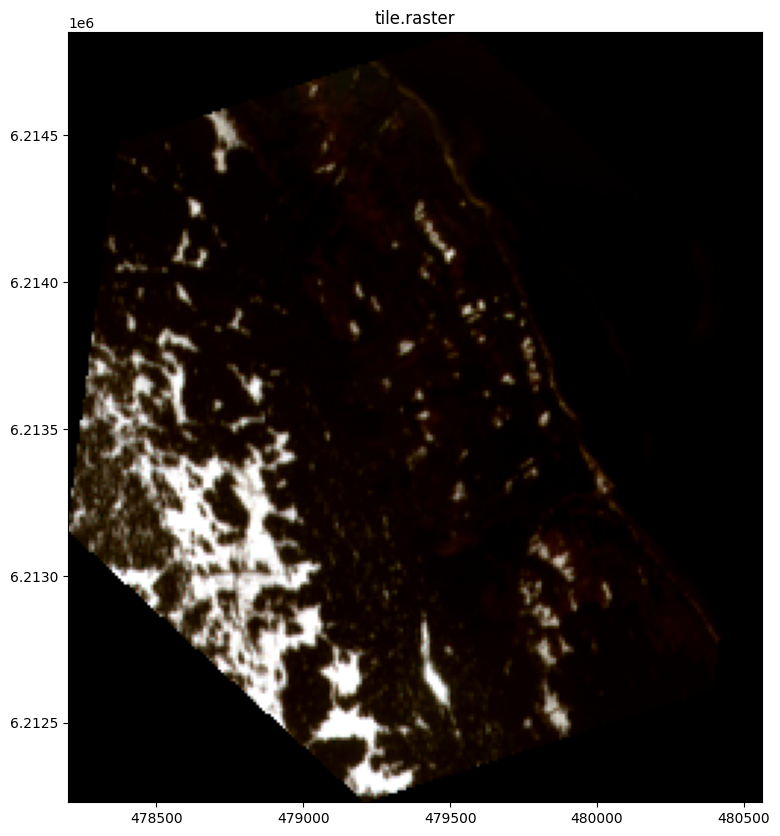

In [0]:
plot_raster(stacked_df.select("tile", "memsize").filter("memsize > 40000").first()["tile"]["raster"])

In [0]:
stacked_df = spark.table("band_stack")
stacked_df.limit(3).display()

cellid,date,tile,memsize,num_bands,px_width,px_height
608313770841735167,2022-06-01,"List(0, ..., Map(driver -> GTiff, width -> 237, height -> 261, count -> 4))",274540,4,237,261
608313768878800895,2022-06-01,"List(0, ..., Map(driver -> GTiff, width -> 237, height -> 261, count -> 4))",285953,4,237,261
608313767654064127,2022-06-01,"List(0, ..., Map(driver -> GTiff, width -> 237, height -> 260, count -> 4))",272064,4,237,260


_We can also write the stacked rasters out to TIF to use in various other operations._

In [0]:
STACKED_DIR = f"{EO_DIR}/out/stacked-tif"
dbutils.fs.mkdirs(STACKED_DIR)

True

In [0]:
num_stacked_files = len(dbutils.fs.ls(STACKED_DIR))
num_stacked_files

28926

`rst_tryopen` validates that each tile can actually be decoded before writing — skipping corrupt or truncated files. `rst_boundingbox` returns the tile's spatial extent as WKB, and `rst_srid` returns its coordinate reference system identifier. See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions).

In [0]:
if FORCE_REBUILD or num_stacked_files == 0:
  if FORCE_REBUILD:
    dbutils.fs.rm(STACKED_DIR, True); dbutils.fs.mkdirs(STACKED_DIR)
  (
    stacked_df
      .filter("num_bands == 4")         # <- skip missing bands   
      .filter("px_width > 10")          # <- skip degenerate post-clip tiles (10×10 = 100)
      .withColumn("source", F.concat_ws("_", "cellid", "date"))  # deterministic filename 
      .repartition(target_partitions, "source")
      .filter(rx.rst_tryopen("tile"))   # <- skip invalid tiles
      .withColumn ("tile", rx.rst_initnodata("tile"))
      .select("source", "tile")  # <- exact (source, tile) schema for gtiff_gbx
      .write
        .format("gtiff_gbx")
        .option("nameCol", "source")
        .mode("append")       # include "append" in the write 
        .option("ext", "tif") # 'tif' (default)
      .save(STACKED_DIR) 
  )
else:
  print("...skipping stacking (already have files, do you need to clean up?)")

...skipping stacking (already have files, do you need to clean up?)


In [0]:
len(dbutils.fs.ls(STACKED_DIR))

28926

## Clipping

> Here is a simple example of clipping each raster to an envelope around the centroid. More sophisticated examples might include clipping to geospatial features or providing a polygon as a spatial filter. 

For clipping, we build a cutline geometry from `st_envelope` (bounding box) + `st_buffer` (padding), convert to EWKB with `st_asewkb` (which carries the SRID), and pass it to `rst_clip`. The SRID embedded in the EWKB cutline tells `rst_clip` which CRS the cutline is in, so it can reproject automatically to the raster's CRS if needed. Note: `st_envelope`, `st_buffer`, `st_centroid`, `st_geomfromwkb`, and `st_asewkb` are Databricks built-in spatial functions (not GeoBrix). See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) and [xView Gotchas](https://databrickslabs.github.io/geobrix/docs/notebooks/xview#gotchas).

In [0]:
df_clip = (
  spark.read.format("gtiff_gbx")
  .load(STACKED_DIR)
  .filter(rx.rst_isempty("tile") == False)
  .withColumn("memsize", rx.rst_memsize("tile"))
  .withColumn("num_bands", rx.rst_numbands("tile"))
  .withColumn("metadata", rx.rst_metadata("tile"))
  .withColumn("summary", rx.rst_summary("tile"))
  .withColumn("srid", rx.rst_srid("tile"))
  .withColumn("bbox", rx.rst_boundingbox("tile"))
  .withColumn("geom", DBF.st_geomfromwkb("bbox", "srid"))           # <- DBF (built-in)
  .withColumn("centroid", DBF.st_centroid("geom"))                  # ^ 
  .withColumn("buffer", DBF.st_buffer("centroid", F.lit(1000)))     # ^ 
  .withColumn("clip_wkb", DBF.st_asewkb(DBF.st_envelope("buffer"))) # ^ 
  .withColumn("clip_tile", rx.rst_clip("tile", "clip_wkb", True))
)

df_clip.limit(1).show(vertical=True)

-RECORD 0-------------------------
 source    | dbfs:/Volumes/geo... 
 tile      | {-1, [49 49 2A 00... 
 memsize   | 144021               
 num_bands | 4                    
 metadata  | {driver -> GTiff,... 
 summary   | {"driverShortName... 
 srid      | 32609                
 bbox      | [01 03 00 00 00 0... 
 geom      | POLYGON((509760 5... 
 centroid  | POINT(509120 5.96... 
 buffer    | POLYGON((510120 5... 
 clip_wkb  | [01 03 00 00 20 6... 
 clip_tile | {-1, [49 49 2A 00... 



In [0]:
# we didn't write the clipped tiles, so this will be a repeat run for the collect()
to_plot = df_clip.select("clip_tile").limit(10).collect()

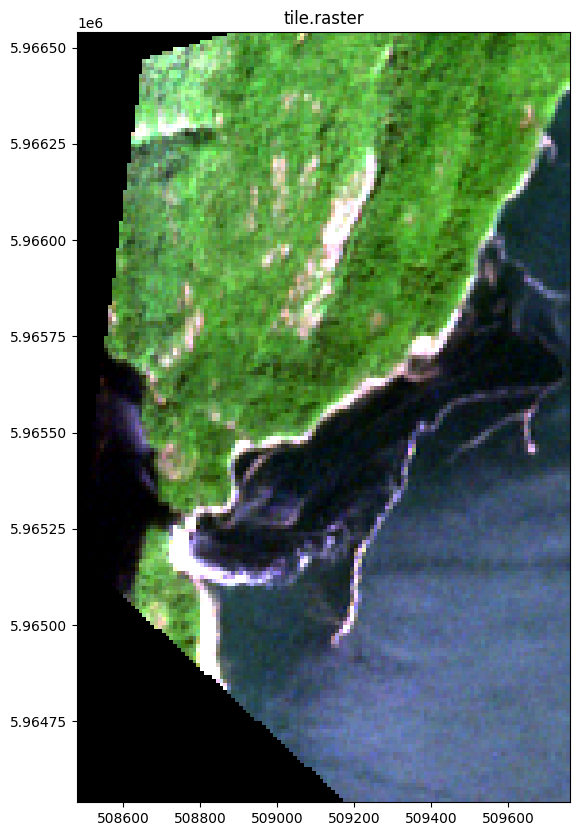

In [0]:
plot_raster(to_plot[0]["clip_tile"]["raster"], fig_w=10, fig_h=10) # <- you may have to change the index, e.g. [5]